# Patient Churn Analysis in Healthcare

## Objective
To analyze patient churn patterns and identify key factors influencing patient retention using exploratory data analysis.

Import Libraries

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Read Data

In [7]:
df = pd.read_csv("../Data/patient_churn_dataset.csv")

EDA

In [11]:
df.columns 
df.info()
df.size
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PatientID                   2000 non-null   str    
 1   Age                         2000 non-null   int64  
 2   Gender                      2000 non-null   str    
 3   State                       2000 non-null   str    
 4   Tenure_Months               2000 non-null   int64  
 5   Specialty                   2000 non-null   str    
 6   Insurance_Type              2000 non-null   str    
 7   Visits_Last_Year            2000 non-null   int64  
 8   Missed_Appointments         2000 non-null   int64  
 9   Days_Since_Last_Visit       2000 non-null   int64  
 10  Last_Interaction_Date       2000 non-null   str    
 11  Overall_Satisfaction        2000 non-null   float64
 12  Wait_Time_Satisfaction      2000 non-null   float64
 13  Staff_Satisfaction          2000 non-null   

,Age,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,52.856500,60.733500,7.614000,2.028000,366.130000,3.255000,3.289900,3.525900,3.736100,836.544000,0.078500,0.206000,1.483500,25.167400,0.683500
std,15.836487,35.111293,4.672143,1.699312,212.890277,1.008595,1.009062,0.871613,0.733748,589.031896,0.269024,0.404532,1.100151,13.948284,0.465227
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.500000,1.500000,2.000000,2.500000,20.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,41.000000,30.000000,4.000000,0.000000,180.000000,2.400000,2.400000,2.775000,3.100000,326.000000,0.000000,0.000000,1.000000,12.800000,0.000000
50%,54.000000,60.000000,8.000000,2.000000,363.000000,3.200000,3.300000,3.500000,3.800000,716.000000,0.000000,0.000000,1.000000,25.000000,1.000000
75%,65.000000,92.250000,12.000000,3.000000,550.250000,4.100000,4.100000,4.300000,4.400000,1368.250000,0.000000,0.000000,2.000000,37.200000,1.000000
max,90.000000,120.000000,15.000000,5.000000,730.000000,5.000000,5.000000,5.000000,5.000000,1999.000000,1.000000,1.000000,3.000000,50.000000,1.000000


In [9]:
df.head(10)

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1
5,C20005,65,Male,MI,82,Orthopedics,Self-Pay,15,1,629,...,1.7,4.9,2.3,4.6,1548,0,1,1,5.6,0
6,C20006,82,Female,FL,56,Pediatrics,Medicare,10,1,520,...,2.9,4.7,3.2,4.5,423,0,1,2,15.8,1
7,C20007,66,Male,MI,22,General Practice,Private,7,0,178,...,2.7,4.7,2.3,4.0,1771,0,0,1,32.1,1
8,C20008,18,Female,FL,39,Orthopedics,Medicare,5,4,492,...,2.9,2.2,2.9,3.3,122,0,0,2,37.7,1
9,C20009,47,Male,NY,15,Internal Medicine,Self-Pay,2,2,298,...,4.4,1.5,2.2,4.2,1685,0,1,2,12.9,0


Checking null and duplicates

In [12]:
df.isna().sum()

PatientID                     0
Age                           0
Gender                        0
State                         0
Tenure_Months                 0
Specialty                     0
Insurance_Type                0
Visits_Last_Year              0
Missed_Appointments           0
Days_Since_Last_Visit         0
Last_Interaction_Date         0
Overall_Satisfaction          0
Wait_Time_Satisfaction        0
Staff_Satisfaction            0
Provider_Rating               0
Avg_Out_Of_Pocket_Cost        0
Billing_Issues                0
Portal_Usage                  0
Referrals_Made                0
Distance_To_Facility_Miles    0
Churned                       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'State', 'Tenure_Months', 'Specialty',
       'Insurance_Type', 'Visits_Last_Year', 'Missed_Appointments',
       'Days_Since_Last_Visit', 'Last_Interaction_Date',
       'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction',
       'Provider_Rating', 'Avg_Out_Of_Pocket_Cost', 'Billing_Issues',
       'Portal_Usage', 'Referrals_Made', 'Distance_To_Facility_Miles',
       'Churned', 'age_group', 'wait_experience'],
      dtype='str')

In [5]:
# Age groups
df['age_group'] = pd.cut(df['Age'],
bins=[0,30,45,60,100],
labels=['18-30','31-45','46-60','60+'])


In [7]:
df['wait_experience'] = pd.cut(df['Wait_Time_Satisfaction'],
bins=[0,2,3,5],
labels=['Poor','Average','Good'])

In [9]:
df['Churned'].value_counts()
df['Gender'].value_counts()

Gender
Male      1016
Female     984
Name: count, dtype: int64

In [18]:
print(df['Insurance_Type'].unique())
print(df['Specialty'].unique())

<StringArray>
['Medicaid', 'Self-Pay', 'Private', 'Medicare']
Length: 4, dtype: str
<StringArray>
[       'Pediatrics', 'Internal Medicine',  'General Practice',
        'Cardiology',       'Orthopedics',         'Neurology',
   'Family Medicine']
Length: 7, dtype: str


In [21]:
df['State'].value_counts()

State
NC    259
IL    214
FL    213
PA    205
NY    197
OH    193
CA    184
GA    181
TX    180
MI    174
Name: count, dtype: int64

In [22]:
df['Specialty'].value_counts()

Specialty
General Practice     302
Orthopedics          289
Family Medicine      289
Neurology            286
Pediatrics           284
Internal Medicine    277
Cardiology           273
Name: count, dtype: int64

In [23]:
df['Churned'].value_counts()

Churned
1    1367
0     633
Name: count, dtype: int64

In [24]:
df['Churned'].value_counts(normalize=True)*100

Churned
1    68.35
0    31.65
Name: proportion, dtype: float64

In [27]:
print("Total Patients:", len(df))
print("Churned:", df['Churned'].sum())
print("Churn Rate:", round(df['Churned'].mean()*100, 2), "%")

Total Patients: 2000
Churned: 1367
Churn Rate: 68.35 %


In [15]:
gender_churn = df.groupby('Gender')['Churned'].mean()*100
print(gender_churn.round(2))
age_churn = df.groupby('age_group')['Churned'].mean()*100
print(age_churn.round(2))

Gender
Female    67.68
Male      69.00
Name: Churned, dtype: float64
age_group
18-30    76.92
31-45    72.20
46-60    65.06
60+      66.43
Name: Churned, dtype: float64


In [16]:
insurance_churn = df.groupby('Insurance_Type')['Churned'].mean()*100
print(insurance_churn.round(2).sort_values(ascending=False))
specialty_churn = df.groupby('Specialty')['Churned'].mean()*100
print(specialty_churn.round(2).sort_values(ascending=False))

Insurance_Type
Medicaid    70.50
Private     69.36
Self-Pay    67.11
Medicare    66.67
Name: Churned, dtype: float64
Specialty
Neurology            70.28
Family Medicine      70.24
Pediatrics           69.72
General Practice     69.54
Internal Medicine    69.31
Cardiology           65.20
Orthopedics          64.01
Name: Churned, dtype: float64


In [32]:
print(df.groupby('Churned')['Overall_Satisfaction'].mean().round(2))
print(df.groupby('Churned')['Wait_Time_Satisfaction'].mean().round(2))
print(df.groupby('Churned')['Staff_Satisfaction'].mean().round(2))

Churned
0    3.48
1    3.15
Name: Overall_Satisfaction, dtype: float64
Churned
0    3.41
1    3.24
Name: Wait_Time_Satisfaction, dtype: float64
Churned
0    3.49
1    3.54
Name: Staff_Satisfaction, dtype: float64


In [17]:
print(df.groupby('Billing_Issues')['Churned'].mean()*100)
print(df.groupby('Churned')['Distance_To_Facility_Miles'].mean().round(2))

Billing_Issues
0    67.607162
1    77.070064
Name: Churned, dtype: float64
Churned
0    23.63
1    25.88
Name: Distance_To_Facility_Miles, dtype: float64


In [19]:
low_satisfaction = df[df['Overall_Satisfaction'] <= 2]
print(f"Low satisfaction patients: {len(low_satisfaction)}")
print(f"Churn rate among them: "f"{low_satisfaction['Churned'].mean()*100:.1f}%")

Low satisfaction patients: 305
Churn rate among them: 78.0%


In [18]:
high_cost = df[df['Avg_Out_Of_Pocket_Cost'] > 
 df['Avg_Out_Of_Pocket_Cost'].quantile(0.75)]
print(f"High cost churn rate: "f"{high_cost['Churned'].mean()*100:.1f}%")


High cost churn rate: 71.8%


Visualization

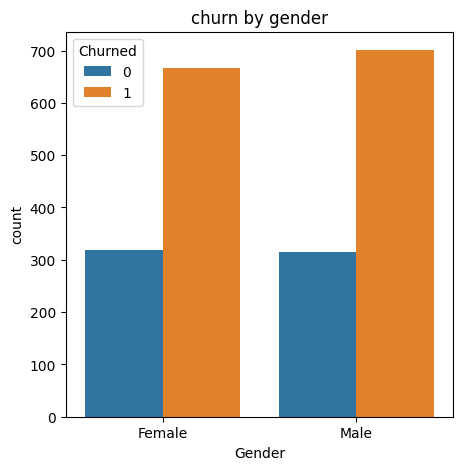

In [9]:
plt.figure(figsize=(5,5))
sns.countplot(data=df,x='Gender',hue='Churned')
plt.title("churn by gender")
plt.show()

Gender difference is minimal

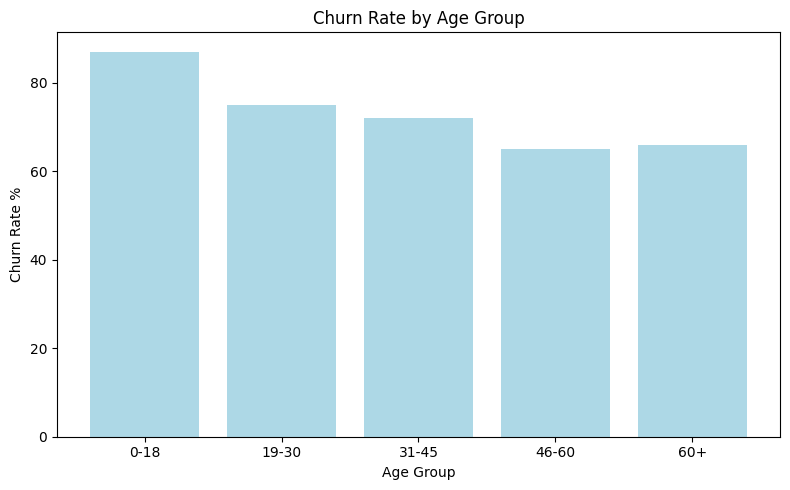

Age_Group
0-18     87.0
19-30    75.0
31-45    72.0
46-60    65.0
60+      66.0
Name: Churned, dtype: float64


In [38]:
age_churn = df.groupby('Age_Group')['Churned'].mean().round(2) * 100
plt.figure(figsize=(8,5))
plt.bar(age_churn.index, age_churn.values, color='lightblue')
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate %')
plt.tight_layout()
plt.show()
print(age_churn)

Younger patients show higher churn compared to older patients.

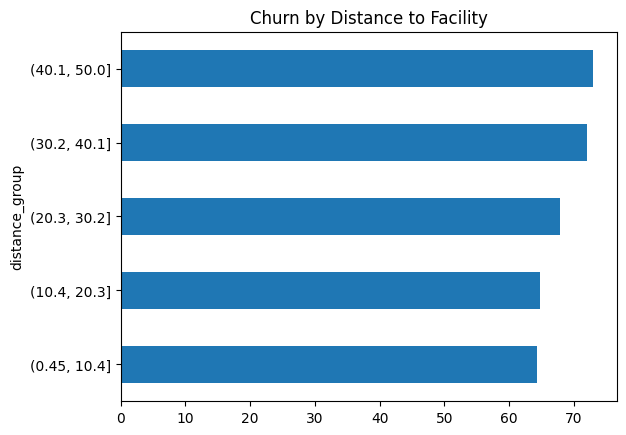

In [8]:

df['distance_group'] = pd.cut(df['Distance_To_Facility_Miles'], bins=5)
(df.groupby('distance_group')['Churned'].mean()*100).sort_values().plot(kind='barh')
plt.title("Churn by Distance to Facility")
plt.show()

Certain locations have significantly higher churn, indicating service gaps.

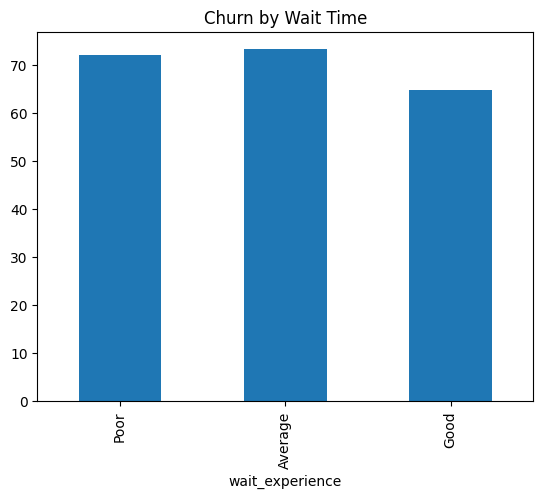

In [25]:
(df.groupby('wait_experience')['Churned'].mean()*100).plot(kind='bar')
plt.title("Churn by Wait Time")
plt.show()

Higher wait times lead to higher churn.

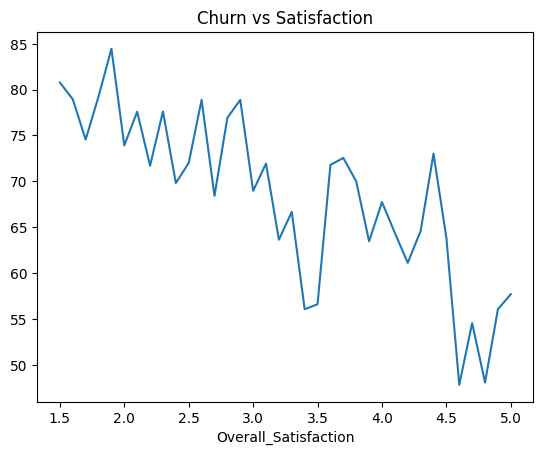

In [44]:
(df.groupby('Overall_Satisfaction')['Churned'].mean()*100).plot()
plt.title("Churn vs Satisfaction")
plt.show()

Higher satisfaction strongly reduces churn.

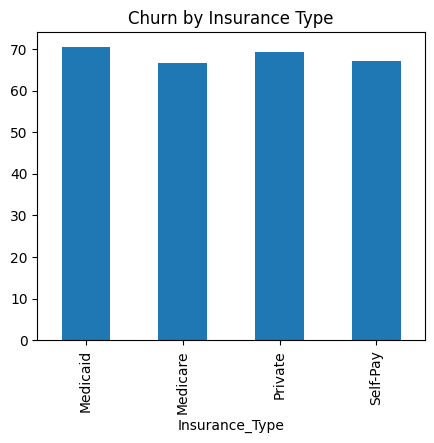

In [34]:
plt.figure(figsize=(5,4))
(df.groupby('Insurance_Type')['Churned'].mean()*100).plot(kind='bar')
plt.title("Churn by Insurance Type")
plt.show()

Although Medicaid shows a slightly higher churn rate, the overall differences across insurance types are small, indicating weak influence on retention.

In [1]:
plt.figure(figsize=(4,4))
missed_churn = df.groupby('Missed_Appointments')['Churned'].mean().round(2) * 100
plt.bar(missed_churn.index, missed_churn.values, color='steelblue')
plt.title('Churn Rate by Missed Appointments')
plt.xlabel('Number of Missed Appointments')
plt.ylabel('Churn Rate %')
plt.tight_layout()
plt.show()
print(missed_churn)

NameError: name 'plt' is not defined

Patients with more missed appointments show higher churn, indicating low engagement leads to drop-off.

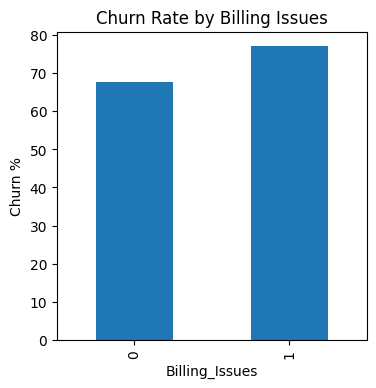

In [31]:
plt.figure(figsize=(4,4))
(df.groupby('Billing_Issues')['Churned'].mean()*100).plot(kind='bar')
plt.title("Churn Rate by Billing Issues")
plt.ylabel("Churn %")
plt.show()

Billing issues lead to higher churn, making them a critical factor affecting patient retention.

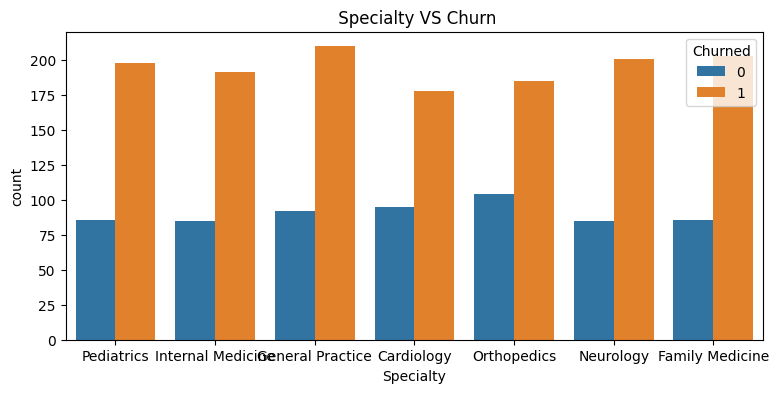

In [14]:
plt.figure(figsize=(9,4))
sns.countplot(data=df , x ='Specialty' , hue = 'Churned')
plt.xlabel("Specialty")
plt.title(" Specialty VS Churn")
plt.show()

Certain medical specialties exhibit higher churn, suggesting service quality or patient experience varies across departments.

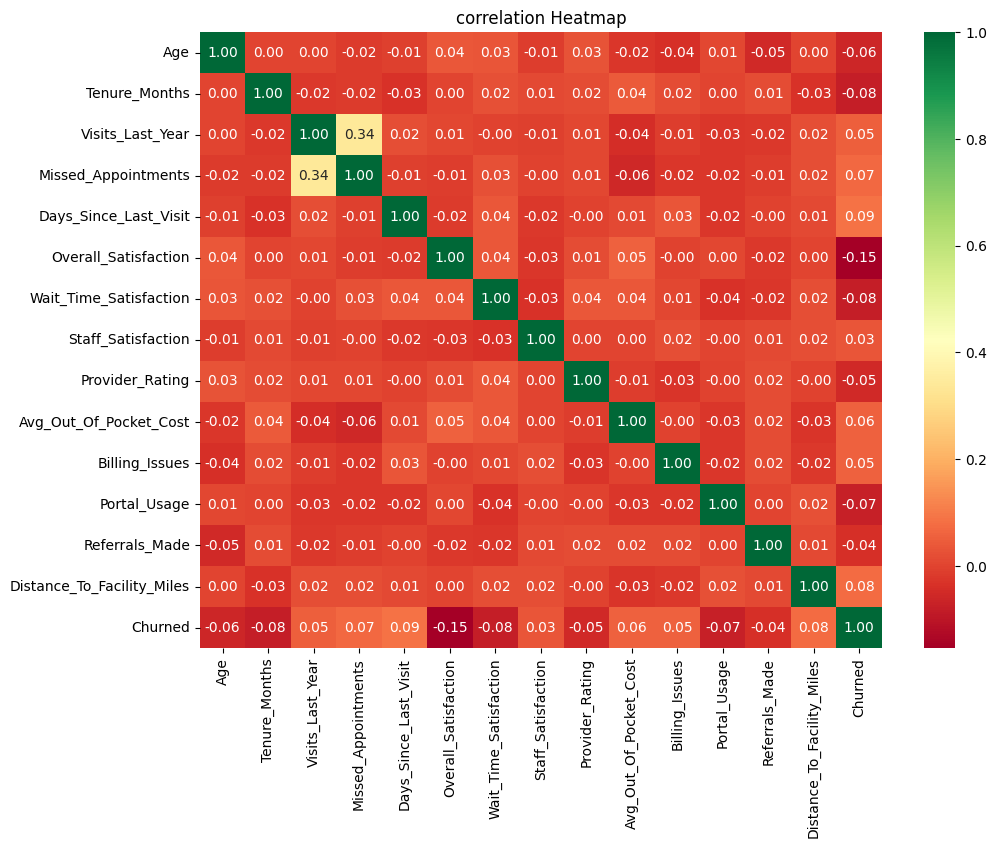

In [ ]:
plt.figure(figsize=(11,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='RdYlGn')
plt.title("correlation Heatmap")
plt.show()

The correlation heatmap shows that satisfaction-related features have a strong negative correlation with churn, indicating that better patient experience reduces churn.